In [1]:
import pandas as pd

In [2]:
data = {
    "name":       ["Alice", "Bob", "Carol", "David", "Eve"],
    "department": ["Engineering", "Finance", "Engineering", "HR", "Finance"],
    "salary":     [85000, 72000, 91000, 65000, 78000],
    "active":     [True, True, False, True, True]
}

df = pd.DataFrame(data)
print(df)

    name   department  salary  active
0  Alice  Engineering   85000    True
1    Bob      Finance   72000    True
2  Carol  Engineering   91000   False
3  David           HR   65000    True
4    Eve      Finance   78000    True


In [3]:
print(df["department"].value_counts())

department
Engineering    2
Finance        2
HR             1
Name: count, dtype: int64


7.4 Selecting Data

In [4]:
print(df["department"]) # for A single column

0    Engineering
1        Finance
2    Engineering
3             HR
4        Finance
Name: department, dtype: object


In [5]:
print(df[["name","department"]]) # returns a DataFrame (one column, still a table)

    name   department
0  Alice  Engineering
1    Bob      Finance
2  Carol  Engineering
3  David           HR
4    Eve      Finance


Selecting Rows — .loc[] and .iloc[]


In [6]:
print(df.loc[0]) # index number

name                Alice
department    Engineering
salary              85000
active               True
Name: 0, dtype: object


In [7]:
print(df.loc[0:2, ["name","active"]])

    name  active
0  Alice    True
1    Bob    True
2  Carol   False


In [8]:
print(df.loc[0:2, "name"])

0    Alice
1      Bob
2    Carol
Name: name, dtype: object


In [9]:
# .iloc — by position
# print(df.iloc[0])              # first row
print(df.iloc[0:2, 0:2])       # rows 0-1, columns 0-1

    name   department
0  Alice  Engineering
1    Bob      Finance


Filtering Rows with Conditions

In [10]:
# Active employees only
active = df[df["active"] == True]
print(active)


    name   department  salary  active
0  Alice  Engineering   85000    True
1    Bob      Finance   72000    True
3  David           HR   65000    True
4    Eve      Finance   78000    True


In [11]:
# engineers
engineers = df[df["department"] == "Engineering"]
print(engineers)

    name   department  salary  active
0  Alice  Engineering   85000    True
2  Carol  Engineering   91000   False


In [12]:
engineers = df[(df["department"] == "Engineering") 
               & (df["salary"] > 90000)]
print(engineers)

    name   department  salary  active
2  Carol  Engineering   91000   False


7.5 Handling Missing Data

In [13]:
data = {
    "name":   ["Alice", "Bob", "Carol", "David"],
    "salary": [85000, None, 91000, 65000],
    "city":   ["Karachi", None, "Lahore", None]
}
df = pd.DataFrame(data)
print(df)

    name   salary     city
0  Alice  85000.0  Karachi
1    Bob      NaN     None
2  Carol  91000.0   Lahore
3  David  65000.0     None


In [14]:
print(df.isnull())

    name  salary   city
0  False   False  False
1  False    True   True
2  False   False  False
3  False   False   True


In [15]:
print(df.isnull().sum())

name      0
salary    1
city      2
dtype: int64


Handling Strategies

Drop rows with any missing value	df.dropna()

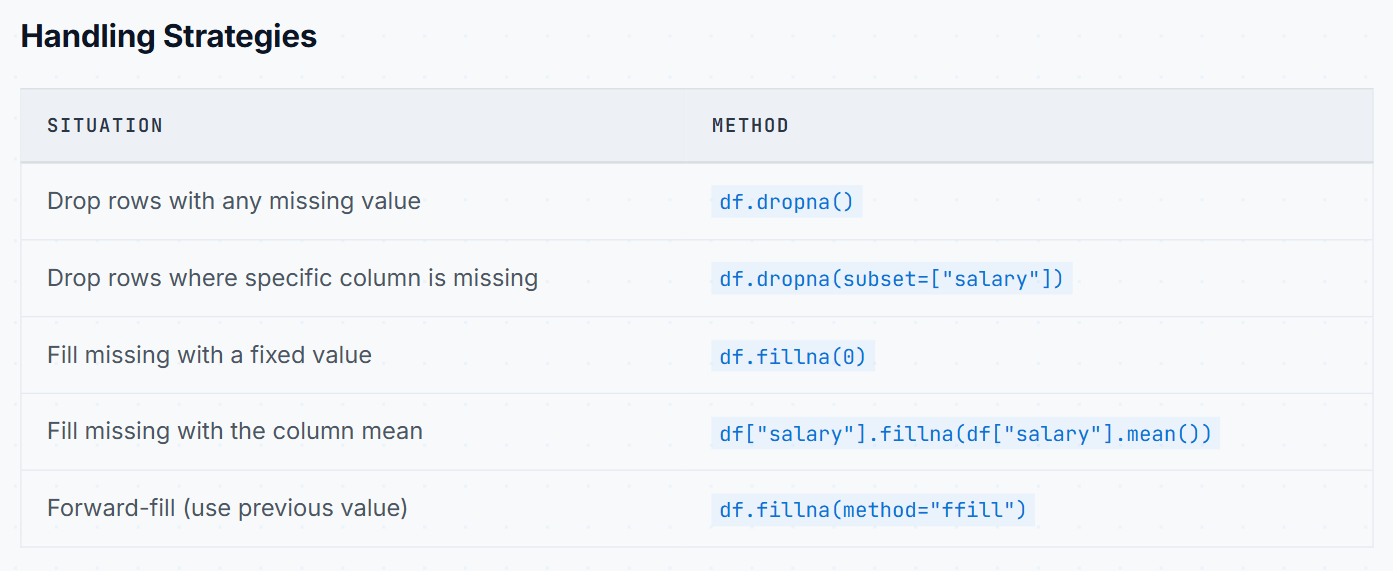

In [16]:
df.dropna()

# when to use --- suppose 10 columns un mai 8 or 9 values hi null row ki or important values null hain then remove 
# the row 

,name,salary,city
0,Alice,85000.0,Karachi
2,Carol,91000.0,Lahore


In [17]:
df.dropna(subset=['salary'])

,name,salary,city
0,Alice,85000.0,Karachi
2,Carol,91000.0,Lahore
3,David,65000.0,None


In [18]:
df.fillna(0)

,name,salary,city
0,Alice,85000.0,Karachi
1,Bob,0.0,0
2,Carol,91000.0,Lahore
3,David,65000.0,0


In [19]:
df['salary'].mean() # avg

np.float64(80333.33333333333)

In [20]:
df['salary'].fillna(df['salary'].mean())

0    85000.000000
1    80333.333333
2    91000.000000
3    65000.000000
Name: salary, dtype: float64

In [21]:
df.fillna(method="ffill") # forward filling -- 

C:\Users\AyanHussain_w5tvk2k\AppData\Local\Temp\ipykernel_23112\2371403560.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill") # forward filling --


,name,salary,city
0,Alice,85000.0,Karachi
1,Bob,85000.0,Karachi
2,Carol,91000.0,Lahore
3,David,65000.0,Lahore


In [22]:
df = df.fillna(method="ffill")

C:\Users\AyanHussain_w5tvk2k\AppData\Local\Temp\ipykernel_23112\567689999.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


In [23]:
df

,name,salary,city
0,Alice,85000.0,Karachi
1,Bob,85000.0,Karachi
2,Carol,91000.0,Lahore
3,David,65000.0,Lahore


7.6 Data Cleaning

Renaming Columns


In [24]:
df = df.rename(columns={
    "name":   "full_name",
    "salary": "annual_salary"
})
print(df.columns)

Index(['full_name', 'annual_salary', 'city'], dtype='object')


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   full_name      4 non-null      object 
 1   annual_salary  4 non-null      float64
 2   city           4 non-null      object 
dtypes: float64(1), object(2)
memory usage: 228.0+ bytes


In [26]:
df['annual_salary'] = df['annual_salary'].astype(int)
df.dtypes

full_name        object
annual_salary     int64
city             object
dtype: object

In [27]:
df['monthly_salary'] = df['annual_salary'] / 12

In [28]:
df

,full_name,annual_salary,city,monthly_salary
0,Alice,85000,Karachi,7083.333333
1,Bob,85000,Karachi,7083.333333
2,Carol,91000,Lahore,7583.333333
3,David,65000,Lahore,5416.666667


In [29]:
df["senior"] = df["annual_salary"] > 80000
df

,full_name,annual_salary,city,monthly_salary,senior
0,Alice,85000,Karachi,7083.333333,True
1,Bob,85000,Karachi,7083.333333,True
2,Carol,91000,Lahore,7583.333333,True
3,David,65000,Lahore,5416.666667,False


In [30]:
def salary_level(salary):
    if salary >= 90000:
        return "Senior"
    elif salary >= 75000:
        return "Mid"
    else:
        return "Junior"

df["rank"] = df["annual_salary"].apply(salary_level)
print(df)

  full_name  annual_salary     city  monthly_salary  senior    rank
0     Alice          85000  Karachi     7083.333333    True     Mid
1       Bob          85000  Karachi     7083.333333    True     Mid
2     Carol          91000   Lahore     7583.333333    True  Senior
3     David          65000   Lahore     5416.666667   False  Junior


In [31]:
df.sort_values("annual_salary",ascending=True)

,full_name,annual_salary,city,monthly_salary,senior,rank
3,David,65000,Lahore,5416.666667,False,Junior
0,Alice,85000,Karachi,7083.333333,True,Mid
1,Bob,85000,Karachi,7083.333333,True,Mid
2,Carol,91000,Lahore,7583.333333,True,Senior


In [32]:
df.sort_values("annual_salary",ascending=False)

,full_name,annual_salary,city,monthly_salary,senior,rank
2,Carol,91000,Lahore,7583.333333,True,Senior
0,Alice,85000,Karachi,7083.333333,True,Mid
1,Bob,85000,Karachi,7083.333333,True,Mid
3,David,65000,Lahore,5416.666667,False,Junior


In [ ]:
df.sort_values("full_name",ascending=True)

df.to_csv("output.csv", index=False)     # index=False prevents writing row numbers

In [86]:
data = {
    "name":       ["Alice", "Bob", "Carol", "David", "Eve"],
    "department": ["Engineering", "Finance", "Engineering", "HR", "Finance"],
    "salary":     [85000, 72000, 91000, 65000, 78000],
    "active":     [True, True, False, True, True]
}

df = pd.DataFrame(data)
# print(df)

In [ ]:
summary = df.groupby("department")['salary'].sum()
print(summary)

department
Engineering    176000
Finance        150000
HR              65000
Name: salary, dtype: int64


In [ ]:
summary = df.groupby("department")['salary'].agg(
    count="count",
    mean="mean",
    max="max",
    sum="sum"
)
print(summary)

             count     mean    max     sum
department                                
Engineering      2  88000.0  91000  176000
Finance          2  75000.0  78000  150000
HR               1  65000.0  65000   65000


In [90]:
employees = pd.DataFrame({
    "id":         [1, 2, 3, 4],
    "name":       ["Alice", "Bob", "Carol", "David"],
    "dept_id":    [10, 20, 10, 30]
})

departments = pd.DataFrame({
    "dept_id":   [10, 20, 40],
    "dept_name": ["Engineering", "Finance", "Marketing"]
})

In [91]:
employees

,id,name,dept_id
0,1,Alice,10
1,2,Bob,20
2,3,Carol,10
3,4,David,30


In [92]:
departments

,dept_id,dept_name
0,10,Engineering
1,20,Finance
2,40,Marketing


In [93]:
inner = pd.merge(employees, departments, on='dept_id', how="inner")
inner

,id,name,dept_id,dept_name
0,1,Alice,10,Engineering
1,2,Bob,20,Finance
2,3,Carol,10,Engineering


In [94]:
# Save to CSV
df.to_csv("output.csv", index=False)     # index=False prevents writing row numbers

# Save to JSON
df.to_json("output.json", orient="records", indent=4)